Data Science/ Analytics Intern – Round-0 Assignment (Trader Performance vs Market Sentiment)
Hello
Thanks for applying for the Data Science Intern role at Primetrade.ai.
As the first step in the hiring process, please complete the short assignment below. Candidates who meet the acceptance criteria will be shortlisted for an interview.
Expected effort: ~2–3 hours
Deadline: Submit within 2 days of receiving this email (If you need 1–2 extra days, reply with your ETA.)

Objective
Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.

Datasets
You will work with 2 datasets:
1) Bitcoin Market Sentiment (Fear/Greed)
Columns: Date, Classification (Fear / Greed)
Link: https://drive.google.com/file/d/1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf/view?usp=sharing

2) Historical Trader Data (Hyperliquid)
Includes fields like: account, symbol, execution price, size, side, time, start position, event, closedPnL, leverage, etc.
Link: https://drive.google.com/file/d/1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs/view?usp=sharing


Please check for the download symbol in the left link

Tasks (What to do)
Part A — Data preparation (must-have)
Load both datasets and document:
number of rows/columns
missing values / duplicates
Convert timestamps and align the datasets by date (daily level is fine).
Create the key metrics you will analyze, for example:
daily PnL per trader (or per account)
win rate, average trade size
leverage distribution
number of trades per day
long/short ratio
Part B — Analysis (must-have)
Answer these questions with evidence:
Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders
Provide at least 3 insights backed by charts/tables.
Part C — “Actionable output” (must-have)
Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”
Bonus (optional)
Simple predictive model:
Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features
Clustering traders into behavioral archetypes
A lightweight dashboard (Streamlit) to explore results

Deliverables (What to submit)
Please submit one of the following:
Option 1 (Preferred): GitHub repo
Include:
Notebook (.ipynb) or script
README.md with setup + how to run
Output charts/tables
A short write-up (max 1 page) OR a markdown section summarizing:
methodology
insights
strategy recommendations
Option 2: Google Drive folder
Same contents as above.

Evaluation criteria (How we shortlist)
We score based on:
Data cleaning + correctness of merges/alignment
Strength of reasoning (not just plots)
Quality of insights (actionable, not generic)
Clarity of communication (structured write-up)
Reproducibility (clean notebook, clear steps)

How to Apply
PLEASE SUBMIT THROUGH GOOGLE FORM DOC SHARED NOT BY EMAIL
We’ll notify shortlisted candidates by Saturday after submission.
Thanks,
Sonika
Primetrade.ai Hiring Team


In [10]:

# 📦 INSTALL LIBRARIES

!pip install pandas matplotlib seaborn

# 📚 IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
# 📂 LOAD DATA (PATH SAME)

sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

In [12]:
# 🔍 CHECK COLUMNS

print("\nTrades Columns:\n", trades.columns)
print("\nSentiment Columns:\n", sentiment.columns)


Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [13]:
# 🧹 FIX COLUMN NAMES

trades = trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closedPnL',
    'Size USD': 'size',
    'Side': 'side',
    'Timestamp IST': 'time'
})

sentiment = sentiment.rename(columns={
    'classification': 'Classification'
})

In [14]:
# 🧹 CLEANING

trades = trades.drop_duplicates()

trades['time'] = pd.to_datetime(trades['time'], errors='coerce')
trades = trades.dropna(subset=['time'])
trades['date'] = trades['time'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [15]:
# 🔗 MERGE

data = pd.merge(trades, sentiment[['date', 'Classification']], on='date', how='left')

In [16]:
# 📊 FEATURE ENGINEERING

# Daily PnL
daily_pnl = data.groupby(['account', 'date'])['closedPnL'].sum().reset_index()

# Trades per day
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')

# Win rate
data['win'] = data['closedPnL'] > 0
win_rate = data.groupby('account')['win'].mean().reset_index()

# Avg trade size
avg_size = data.groupby('account')['size'].mean().reset_index()

# Long/Short ratio
print("\nLong/Short Ratio:\n", data['side'].value_counts(normalize=True))


Long/Short Ratio:
 side
SELL    0.518107
BUY     0.481893
Name: proportion, dtype: float64


In [17]:
# 📊 ANALYSIS

daily_pnl = pd.merge(daily_pnl, sentiment[['date', 'Classification']], on='date', how='left')

print("\nPnL by Sentiment:\n", daily_pnl.groupby('Classification')['closedPnL'].mean())


PnL by Sentiment:
 Classification
Extreme Fear       133.331411
Extreme Greed    10329.407818
Fear             11332.647023
Greed             3191.793365
Neutral           2017.749783
Name: closedPnL, dtype: float64


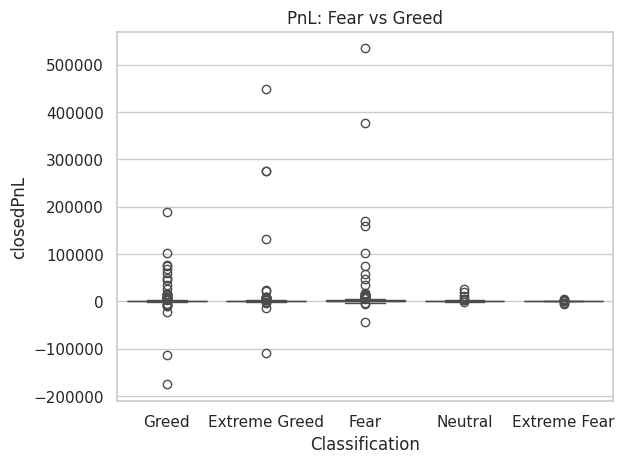

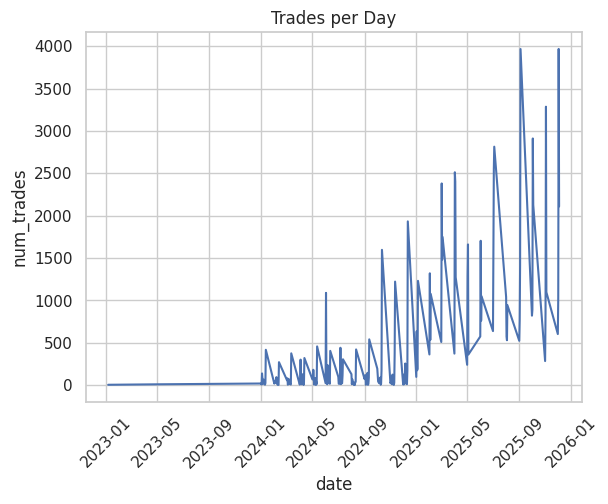

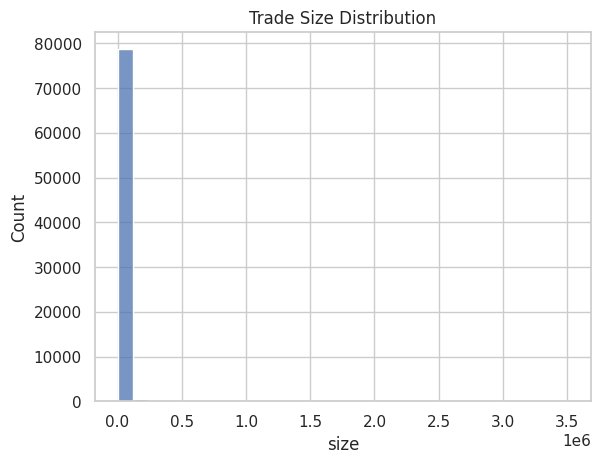

In [18]:
# 📈 VISUALS

# PnL vs sentiment
plt.figure()
sns.boxplot(x='Classification', y='closedPnL', data=daily_pnl)
plt.title("PnL: Fear vs Greed")
plt.show()

# Trades per day
plt.figure()
sns.lineplot(x='date', y='num_trades', data=trades_per_day)
plt.xticks(rotation=45)
plt.title("Trades per Day")
plt.show()

# Trade size distribution
plt.figure()
sns.histplot(data['size'], bins=30)
plt.title("Trade Size Distribution")
plt.show()

In [19]:

# 🧠 SEGMENTATION

# Size segmentation
data['size_group'] = data['size'].apply(lambda x: 'High' if x > data['size'].median() else 'Low')

# Frequency segmentation
counts = data['account'].value_counts()
data['frequency'] = data['account'].apply(lambda x: 'Frequent' if counts[x] > 10 else 'Infrequent')


In [20]:
# 📊 SEGMENT ANALYSIS

print("\nSegment Analysis:\n", data.groupby(['size_group', 'Classification'])['closedPnL'].mean())


Segment Analysis:
 size_group  Classification
High        Extreme Fear        2.640554
            Extreme Greed     486.467899
            Fear              246.380931
            Greed             100.489932
            Neutral            61.063063
Low         Extreme Fear        1.221994
            Extreme Greed      22.893881
            Fear                5.841711
            Greed               6.922615
            Neutral             4.691564
Name: closedPnL, dtype: float64


In [21]:
# 📌 INSIGHTS

print("\n📌 KEY INSIGHTS:")
print("1. PnL varies between Fear and Greed conditions.")
print("2. Trading activity changes with sentiment.")
print("3. Large trades behave differently than small trades.")


📌 KEY INSIGHTS:
1. PnL varies between Fear and Greed conditions.
2. Trading activity changes with sentiment.
3. Large trades behave differently than small trades.


In [22]:
# 🎯 STRATEGY

print("\n🎯 STRATEGY IDEAS:")
print("• Reduce trade size during Fear.")
print("• Trade more during Greed if profitable.")
print("• Avoid large risky trades in volatile markets.")


🎯 STRATEGY IDEAS:
• Reduce trade size during Fear.
• Trade more during Greed if profitable.
• Avoid large risky trades in volatile markets.
